# 06 - Severity Prediction Model

This notebook builds a machine learning model to predict CVE severity levels from text features.

Models evaluated:
- Logistic Regression
- Random Forest

Features:
- TF-IDF vectors from CVE descriptions
- Vulnerability type (one-hot encoded)

Target: Severity (Low, Medium, High, Critical)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack
import joblib
import sys
sys.path.append('..')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

## 1. Load and Prepare Data

In [2]:
df = pd.read_csv('../data/cve_with_keywords.csv')
print(f"Total records: {len(df)}")

# Filter valid severity labels
valid_severities = ['Low', 'Medium', 'High', 'Critical']
df_model = df[df['Severity'].isin(valid_severities)].copy()
print(f"Records with valid severity: {len(df_model)}")

print(f"\nSeverity distribution:")
print(df_model['Severity'].value_counts())

Total records: 1314
Records with valid severity: 1314

Severity distribution:
Severity
Medium      602
High        465
Critical    169
Low          78
Name: count, dtype: int64


## 2. Feature Engineering

In [3]:
# TF-IDF features from cleaned descriptions
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df_model['Cleaned_Description'].fillna(''))
print(f"TF-IDF features: {X_tfidf.shape}")

# Vulnerability type features (one-hot)
vuln_dummies = pd.get_dummies(df_model['Vulnerability_Type'], prefix='vuln')
from scipy.sparse import csr_matrix
X_vuln = csr_matrix(vuln_dummies.values)
print(f"Vulnerability type features: {X_vuln.shape}")

# Combine features
X = hstack([X_tfidf, X_vuln])
print(f"Combined feature matrix: {X.shape}")

# Encode target
severity_encoder = LabelEncoder()
y = severity_encoder.fit_transform(df_model['Severity'])
print(f"Classes: {list(severity_encoder.classes_)}")

TF-IDF features: (1314, 3000)
Vulnerability type features: (1314, 13)
Combined feature matrix: (1314, 3013)
Classes: ['Critical', 'High', 'Low', 'Medium']


In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 1051, Test: 263


## 3. Train Logistic Regression

In [5]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)

print("Logistic Regression Results:")
print(f"Accuracy: {lr_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=severity_encoder.classes_, zero_division=0))

Logistic Regression Results:
Accuracy: 0.7034

Classification Report:
              precision    recall  f1-score   support

    Critical       0.62      0.59      0.61        34
        High       0.71      0.63      0.67        93
         Low       0.50      0.69      0.58        16
      Medium       0.75      0.79      0.77       120

    accuracy                           0.70       263
   macro avg       0.65      0.68      0.66       263
weighted avg       0.71      0.70      0.70       263



## 4. Train Random Forest

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=42, n_jobs=-1, max_depth=30
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print("Random Forest Results:")
print(f"Accuracy: {rf_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=severity_encoder.classes_, zero_division=0))

Random Forest Results:
Accuracy: 0.6920

Classification Report:
              precision    recall  f1-score   support

    Critical       0.82      0.41      0.55        34
        High       0.63      0.69      0.66        93
         Low       0.89      0.50      0.64        16
      Medium       0.71      0.80      0.75       120

    accuracy                           0.69       263
   macro avg       0.76      0.60      0.65       263
weighted avg       0.71      0.69      0.69       263



## 5. Model Comparison

In [7]:
# Compare models
models = {'Logistic Regression': (lr_model, lr_preds, lr_acc),
          'Random Forest': (rf_model, rf_preds, rf_acc)}

print("Model Comparison:")
print("=" * 40)
for name, (model, preds, acc) in models.items():
    print(f"  {name}: {acc:.4f}")

# Select best model
best_name = max(models, key=lambda k: models[k][2])
best_model, best_preds, best_acc = models[best_name]
print(f"\nBest model: {best_name} (accuracy: {best_acc:.4f})")

Model Comparison:
  Logistic Regression: 0.7034
  Random Forest: 0.6920

Best model: Logistic Regression (accuracy: 0.7034)


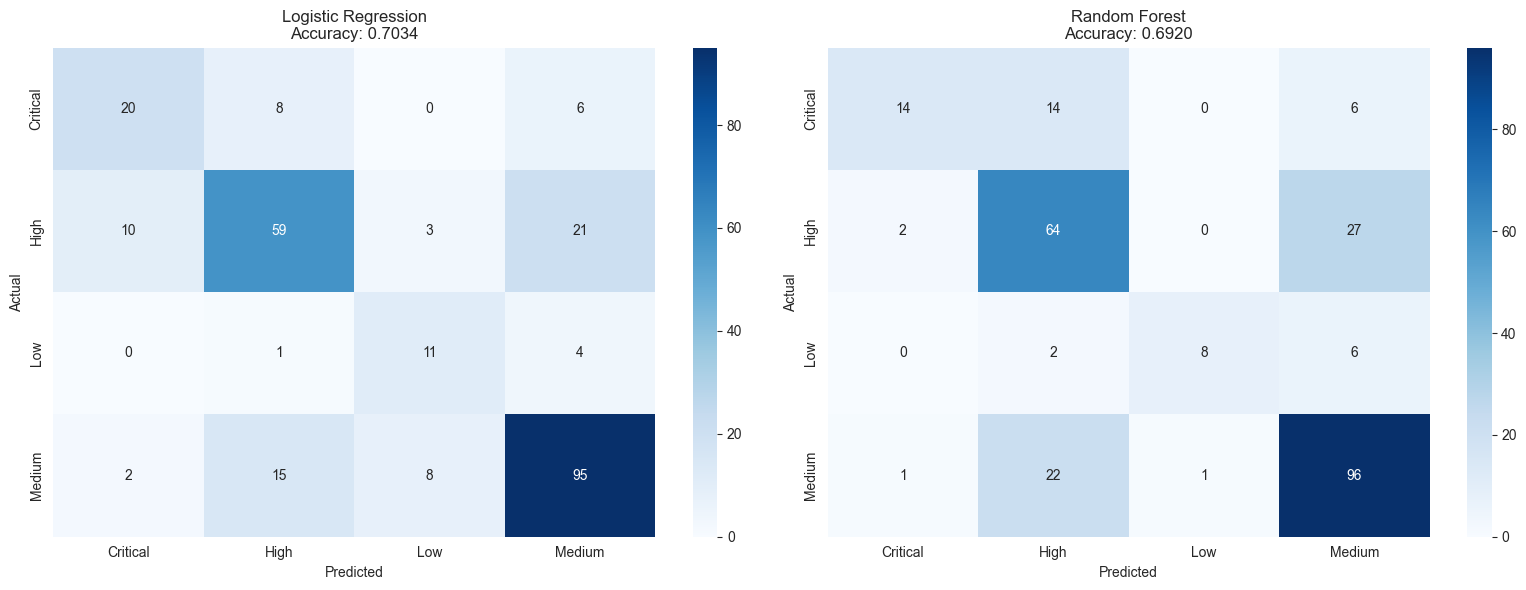

In [8]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, (model, preds, acc)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=severity_encoder.classes_,
                yticklabels=severity_encoder.classes_)
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../models/severity_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cross-Validation

In [9]:
# 5-fold cross-validation
print("5-Fold Cross-Validation Scores:")
print("=" * 40)

for name in ['Logistic Regression', 'Random Forest']:
    model = models[name][0]
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    print(f"{name}:")
    print(f"  Mean: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")
    print(f"  Scores: {[f'{s:.4f}' for s in scores]}")

5-Fold Cross-Validation Scores:
Logistic Regression:
  Mean: 0.5351 (+/- 0.0932)
  Scores: ['0.5589', '0.5475', '0.5247', '0.4525', '0.5916']
Random Forest:
  Mean: 0.5335 (+/- 0.0824)
  Scores: ['0.5095', '0.5703', '0.5399', '0.4677', '0.5802']


## 7. Feature Importance (Random Forest)

Top 20 Features for Severity Prediction:
  problematic                         0.0112
  function                            0.0093
  version                             0.0090
  injection                           0.0078
  via                                 0.0078
  cross                               0.0074
  site scripting                      0.0070
  manipulation                        0.0068
  scripting                           0.0068
  cross site                          0.0066
  parameter                           0.0066
  injection vulnerability             0.0061
  command                             0.0061
  lead cross                          0.0054
  disclosed                           0.0054
  found                               0.0054
  may                                 0.0054
  vuln_Cross-Site Scripting (XSS)     0.0051
  vulnerability                       0.0051
  identifier                          0.0050


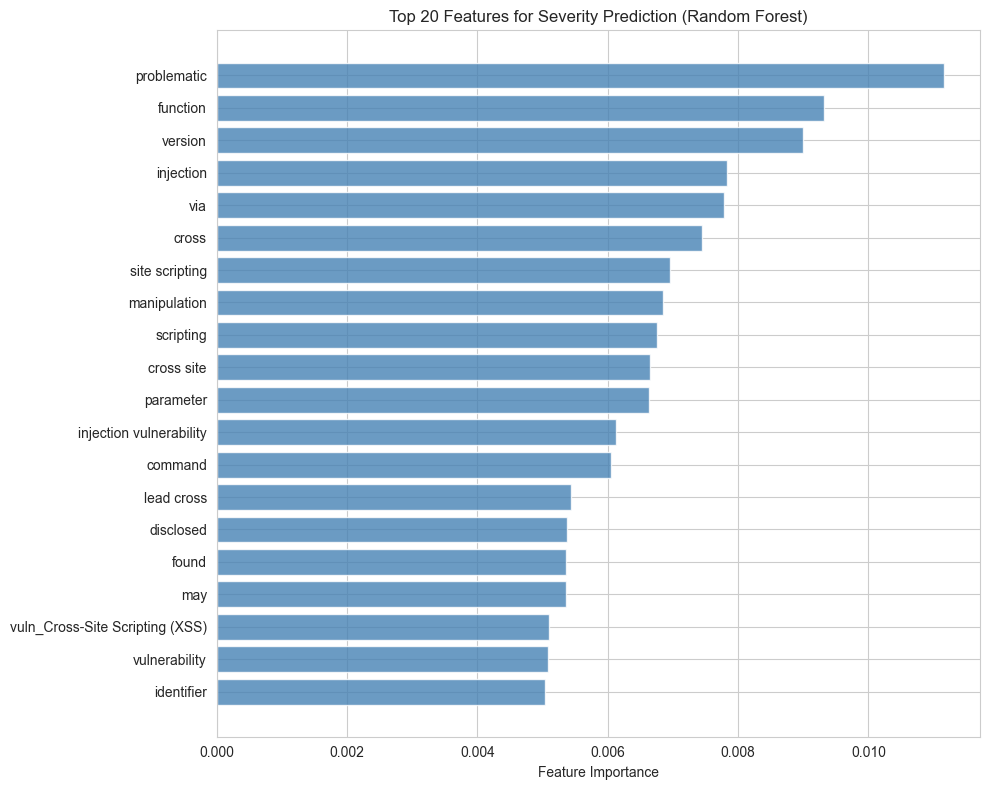

In [10]:
# Get all feature names
tfidf_features = tfidf.get_feature_names_out()
vuln_features = vuln_dummies.columns.tolist()
all_features = list(tfidf_features) + vuln_features

# Top 20 important features from Random Forest
importances = rf_model.feature_importances_
top_20_idx = importances.argsort()[::-1][:20]
top_20_features = [(all_features[i], importances[i]) for i in top_20_idx]

print("Top 20 Features for Severity Prediction:")
for feat, imp in top_20_features:
    print(f"  {feat:35s} {imp:.4f}")

# Plot
plt.figure(figsize=(10, 8))
plt.barh([f[0] for f in reversed(top_20_features)],
         [f[1] for f in reversed(top_20_features)],
         color='steelblue', alpha=0.8)
plt.xlabel('Feature Importance')
plt.title('Top 20 Features for Severity Prediction (Random Forest)')
plt.tight_layout()
plt.show()

## 8. Save Best Model

In [11]:
# Save the best model and associated artifacts
joblib.dump(best_model, '../models/severity_predictor.joblib')
joblib.dump(tfidf, '../models/severity_tfidf.joblib')
joblib.dump(severity_encoder, '../models/severity_encoder.joblib')

# Save the vulnerability type columns for one-hot encoding
joblib.dump(list(vuln_dummies.columns), '../models/severity_vuln_columns.joblib')

print(f"Best model ({best_name}) saved!")
print(f"Accuracy: {best_acc:.4f}")
print("\nSaved artifacts:")
print("  - models/severity_predictor.joblib")
print("  - models/severity_tfidf.joblib")
print("  - models/severity_encoder.joblib")
print("  - models/severity_vuln_columns.joblib")
print("\n✅ Severity prediction model complete!")

Best model (Logistic Regression) saved!
Accuracy: 0.7034

Saved artifacts:
  - models/severity_predictor.joblib
  - models/severity_tfidf.joblib
  - models/severity_encoder.joblib
  - models/severity_vuln_columns.joblib

✅ Severity prediction model complete!
